## Chargement & aperçu général

In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("../data/raw/reviews_all_beauty.csv")

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\nColonnes : {df.columns.tolist()}")
print(f"\nTypes de données :\n{df.dtypes}")


Dimensions : 701,528 lignes × 10 colonnes

Colonnes : ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Types de données :
rating               float64
title                    str
text                     str
images                   str
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [2]:
# Aperçu des premières lignes
df.head(3)


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [3]:
# Valeurs manquantes en %
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"Manquants": missing, "Pourcentage (%)": missing_pct})


,Manquants,Pourcentage (%)
rating,0,0.00
title,160,0.02
text,212,0.03
images,0,0.00
asin,0,0.00
parent_asin,0,0.00
user_id,0,0.00
timestamp,0,0.00
helpful_vote,0,0.00
verified_purchase,0,0.00


## Distribution des notes (ratings)

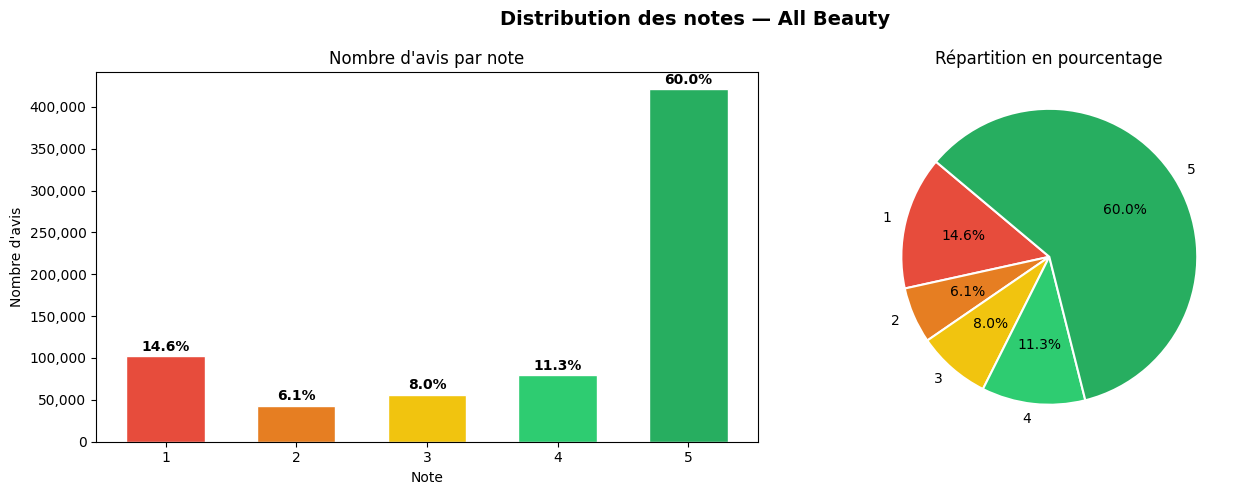

Moyenne : 3.96 | Médiane : 5.0 | Écart-type : 1.49


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Calcul des effectifs et pourcentages
rating_counts = df['rating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(1)

# Couleurs : rouge pour les mauvaises notes, vert pour les bonnes
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des notes — All Beauty", fontsize=14, fontweight='bold')

# --- Barplot ---
bars = axes[0].bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white', width=0.6)
axes[0].set_xlabel("Note")
axes[0].set_ylabel("Nombre d'avis")
axes[0].set_title("Nombre d'avis par note")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotation du % sur chaque barre
for bar, pct in zip(bars, rating_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
                 f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Pie chart ---
axes[1].pie(rating_counts.values, labels=[f'{int(r)}' for r in rating_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("../outputs/distribution_ratings.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Moyenne : {df['rating'].mean():.2f} | Médiane : {df['rating'].median():.1f} | Écart-type : {df['rating'].std():.2f}")

### 1. Biais de positivité massif
60% des avis sont à 5 étoiles, médiane = 5.0. C'est le J-curve effect classique sur Amazon : les clients satisfaits laissent spontanément un avis, les autres s'abstiennent souvent.

### 2. Creux au milieu (notes 2 et 3)
Les notes 2 et 3 représentent seulement 14% combinées. Les utilisateurs ont tendance à mettre soit un avis très positif, soit très négatif — rarement nuancé.

### 3. Les 1 étoile sont significatifs (14.5%)
C'est un signal fort : des produits clairement décevants existent. Ces avis négatifs sont précieux pour la reco — éviter de recommander ces produits.

### 4. Moyenne ≠ Médiane → distribution asymétrique
Moyenne : 3.96 / Médiane : 5.0
L'écart montre que la distribution est fortement asymétrique à gauche (skewed). La moyenne est tirée vers le bas par les 1 étoiles.

## Distribution du nombre d'avis par utilisateur

In [5]:
# Nombre d'avis par utilisateur
reviews_per_user = df.groupby('user_id').size()

# Statistiques clés
print("=== Statistiques ===")
print(f"Min    : {reviews_per_user.min()}")
print(f"Max    : {reviews_per_user.max()}")
print(f"Moyenne: {reviews_per_user.mean():.2f}")
print(f"Médiane: {reviews_per_user.median():.0f}")

print("\n=== Répartition par seuil ===")
for seuil in [1, 2, 3, 5, 10]:
    n = (reviews_per_user >= seuil).sum()
    pct = n / len(reviews_per_user) * 100
    print(f"≥ {seuil:2d} avis : {n:>7,} utilisateurs ({pct:.1f}%)")

=== Statistiques ===
Min    : 1
Max    : 165
Moyenne: 1.11
Médiane: 1

=== Répartition par seuil ===
≥  1 avis : 631,986 utilisateurs (100.0%)
≥  2 avis :  48,433 utilisateurs (7.7%)
≥  3 avis :   9,159 utilisateurs (1.4%)
≥  5 avis :   1,620 utilisateurs (0.3%)
≥ 10 avis :     330 utilisateurs (0.1%)


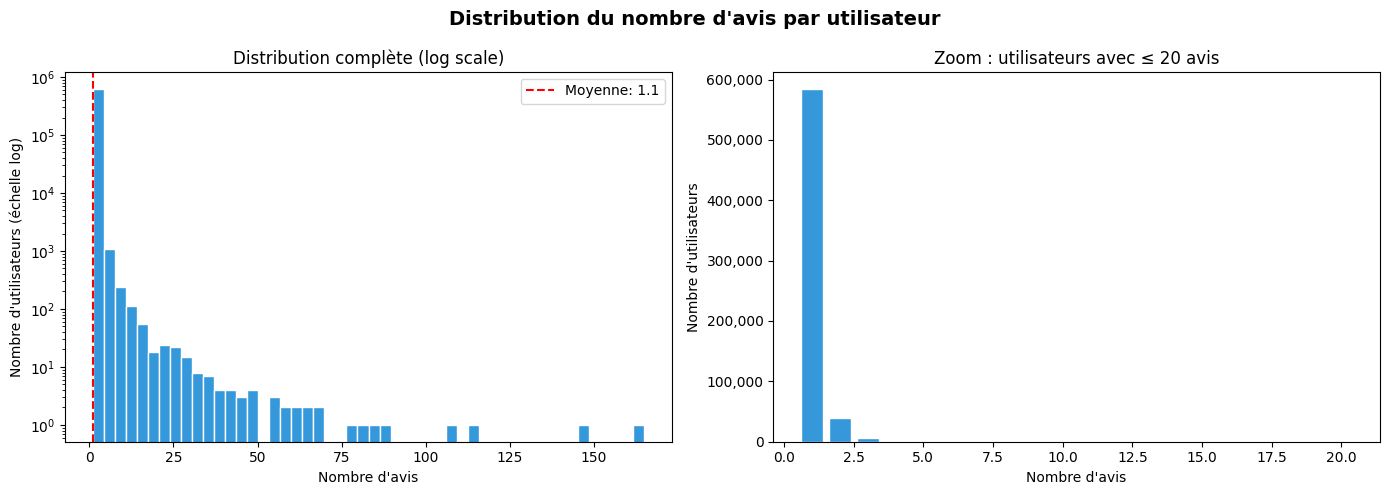

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution du nombre d'avis par utilisateur", fontsize=14, fontweight='bold')

# --- Histogramme en échelle log (tous les utilisateurs) ---
axes[0].hist(reviews_per_user, bins=50, color='#3498db', edgecolor='white', log=True)
axes[0].set_xlabel("Nombre d'avis")
axes[0].set_ylabel("Nombre d'utilisateurs (échelle log)")
axes[0].set_title("Distribution complète (log scale)")
axes[0].axvline(reviews_per_user.mean(), color='red', linestyle='--', label=f'Moyenne: {reviews_per_user.mean():.1f}')
axes[0].legend()

# --- Zoom sur les utilisateurs avec ≤ 20 avis ---
zoom = reviews_per_user[reviews_per_user <= 20].value_counts().sort_index()
axes[1].bar(zoom.index, zoom.values, color='#3498db', edgecolor='white')
axes[1].set_xlabel("Nombre d'avis")
axes[1].set_ylabel("Nombre d'utilisateurs")
axes[1].set_title("Zoom : utilisateurs avec ≤ 20 avis")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig("../outputs/distribution_avis_utilisateurs.png", dpi=150, bbox_inches='tight')
plt.show()

## Évolution temporelle des avis

In [7]:
# Le timestamp est en millisecondes → conversion en datetime
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
df['year_month'] = df['date'].dt.to_period('M')

print("=== Période couverte ===")
print(f"Du  : {df['date'].min().strftime('%B %Y')}")
print(f"Au  : {df['date'].max().strftime('%B %Y')}")
print(f"Durée : {(df['date'].max() - df['date'].min()).days // 365} ans")

=== Période couverte ===
Du  : November 2000
Au  : September 2023
Durée : 22 ans


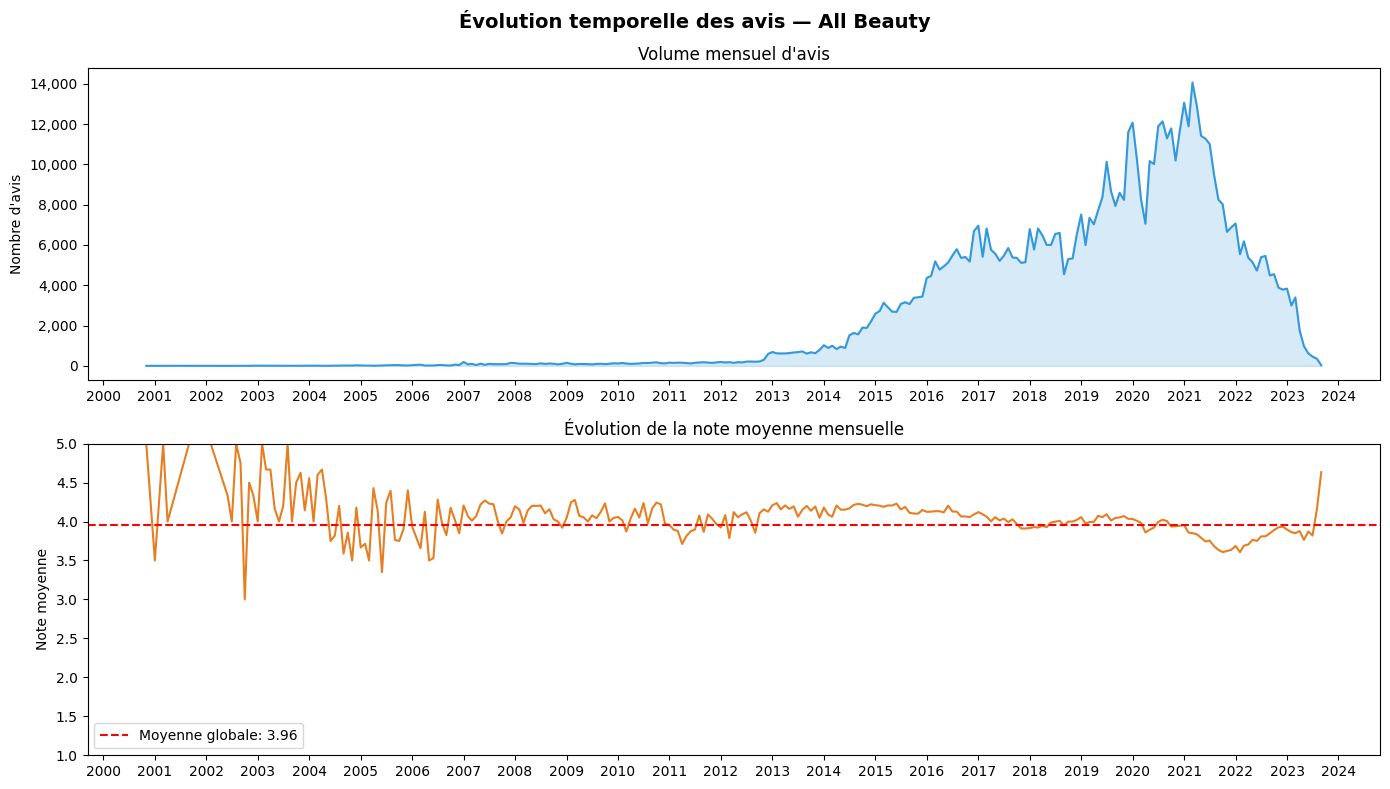

In [8]:
# Nombre d'avis par mois
avis_par_mois = df.groupby('year_month').size()
note_par_mois = df.groupby('year_month')['rating'].mean()

# Conversion en index datetime pour mieux contrôler les ticks
index_dt = avis_par_mois.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Évolution temporelle des avis — All Beauty", fontsize=14, fontweight='bold')

# --- Volume d'avis par mois ---
axes[0].plot(index_dt, avis_par_mois.values, color='#3498db', linewidth=1.5)
axes[0].fill_between(index_dt, avis_par_mois.values, alpha=0.2, color='#3498db')
axes[0].set_ylabel("Nombre d'avis")
axes[0].set_title("Volume mensuel d'avis")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# 1 tick par an uniquement
axes[0].xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
axes[0].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# --- Note moyenne par mois ---
axes[1].plot(index_dt, note_par_mois.values, color='#e67e22', linewidth=1.5)
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--', label=f'Moyenne globale: {df["rating"].mean():.2f}')
axes[1].set_ylabel("Note moyenne")
axes[1].set_title("Évolution de la note moyenne mensuelle")
axes[1].set_ylim(1, 5)
axes[1].xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/evolution_temporelle.png", dpi=150, bbox_inches='tight')
plt.show()

Le dataset couvre une très longue période, mais les données avant 2013 sont quasi-inexistantes. L'essentiel des avis se concentre sur 2015–2022 — c'est la fenêtre vraiment exploitable.

Le pic de 2020-2021 coïncide avec le Covid : explosion des achats en ligne et donc des avis. Le top 3 des mois les plus actifs sont tous en début 2021

Le volume baisse de 50% en 2022, probablement dû à la politique Amazon contre les faux avis (purge massive en 2021-2022) + retour à la normale post-Covid.

La note moyenne passe de ~4.15 (2013-2016) à 3.77 (2021-2022). Les consommateurs sont devenus plus exigeants, ou les faux avis positifs ont été supprimés.


## Analyse des produits les plus reviewés

In [9]:
# Statistiques par produit
produit_stats = df.groupby('asin').agg(
    nb_avis=('rating', 'count'),
    note_moyenne=('rating', 'mean'),
    note_ecart=('rating', 'std')
).round(2)

print("=== Distribution des avis par produit ===")
print(f"Produits avec 1 seul avis  : {(produit_stats['nb_avis'] == 1).sum():,} ({(produit_stats['nb_avis'] == 1).mean()*100:.1f}%)")
print(f"Produits avec ≥ 5 avis     : {(produit_stats['nb_avis'] >= 5).sum():,} ({(produit_stats['nb_avis'] >= 5).mean()*100:.1f}%)")
print(f"Produits avec ≥ 10 avis    : {(produit_stats['nb_avis'] >= 10).sum():,} ({(produit_stats['nb_avis'] >= 10).mean()*100:.1f}%)")

print("\n=== Top 10 produits les plus reviewés ===")
top10 = produit_stats.sort_values('nb_avis', ascending=False).head(10)
print(top10)

=== Distribution des avis par produit ===
Produits avec 1 seul avis  : 48,859 (42.2%)
Produits avec ≥ 5 avis     : 28,344 (24.5%)
Produits avec ≥ 10 avis    : 13,617 (11.8%)

=== Top 10 produits les plus reviewés ===
            nb_avis  note_moyenne  note_ecart
asin                                         
B007IAE5WY     1962          4.62        0.97
B00EEN2HCS     1750          4.14        1.35
B07C533XCW     1513          4.47        1.19
B00R1TAN7I     1372          4.03        1.37
B08L5KN7X4     1343          4.02        1.57
B019GBG0IE     1328          3.53        1.57
B0719KWG8H     1168          4.48        1.14
B0092MCQZ4     1128          3.98        1.49
B0107QYW14     1112          3.93        1.39
B0070Z7KME      934          4.28        1.26


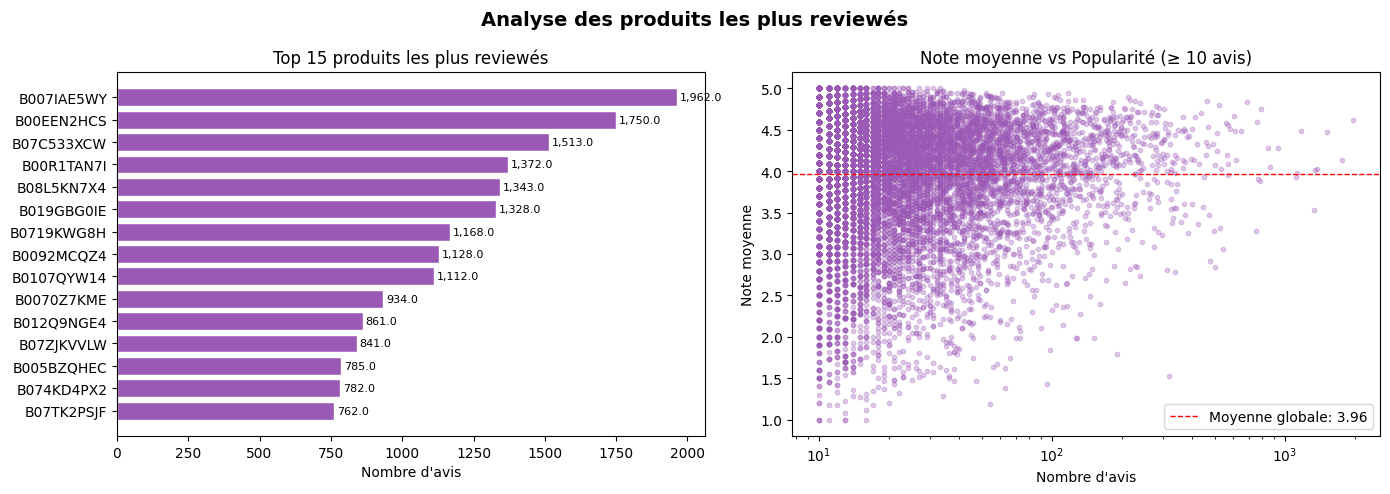

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse des produits les plus reviewés", fontsize=14, fontweight='bold')

# --- Top 15 produits par nombre d'avis ---
top15 = produit_stats.sort_values('nb_avis', ascending=False).head(15)
axes[0].barh(top15.index[::-1], top15['nb_avis'][::-1], color='#9b59b6', edgecolor='white')
axes[0].set_xlabel("Nombre d'avis")
axes[0].set_title("Top 15 produits les plus reviewés")
for i, (asin, row) in enumerate(top15[::-1].iterrows()):
    axes[0].text(row['nb_avis'] + 10, i, f"{row['nb_avis']:,}", va='center', fontsize=8)

# --- Note moyenne vs nombre d'avis (scatter) ---
# On filtre les produits avec ≥ 10 avis pour plus de lisibilité
produits_actifs = produit_stats[produit_stats['nb_avis'] >= 10]
axes[1].scatter(produits_actifs['nb_avis'], produits_actifs['note_moyenne'],
                alpha=0.3, s=10, color='#9b59b6')
axes[1].set_xlabel("Nombre d'avis")
axes[1].set_ylabel("Note moyenne")
axes[1].set_title("Note moyenne vs Popularité (≥ 10 avis)")
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--', linewidth=1,
                label=f'Moyenne globale: {df["rating"].mean():.2f}')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/analyse_produits.png", dpi=150, bbox_inches='tight')
plt.show()

Sur 115 709 produits, seulement 24.5% ont 5 avis ou plus. C'est le même problème de sparsité côté produits que côté utilisateurs — la majorité des produits est trop peu connue pour être recommandée avec confiance.

Le produit leader cumule 1 962 avis avec une note de 4.62 — c'est un best-seller probable.

plus un produit est reviewé, plus sa note est élevée.

Scatter plot : 
Les produits peu reviewés ont des notes très dispersées

Plus le produit accumule d'avis, plus sa note converge vers 4.0-4.5.


## Matrice utilisateur-produit et sparsité

In [11]:
# --- Sparsité sur le dataset complet ---
n_users = df['user_id'].nunique()
n_items = df['asin'].nunique()
n_ratings = len(df)
total_cells = n_users * n_items
sparsite = (1 - n_ratings / total_cells) * 100

print("=== Matrice complète ===")
print(f"Utilisateurs : {n_users:,}")
print(f"Produits     : {n_items:,}")
print(f"Cases totales: {total_cells:,}")
print(f"Notes renseignées : {n_ratings:,}")
print(f"Sparsité     : {sparsite:.4f}%")

# --- Sparsité après filtrage (utilisateurs ≥ 3 avis, produits ≥ 5 avis) ---
print("\n=== Après filtrage (users ≥ 3 avis, produits ≥ 5 avis) ===")
users_actifs = df['user_id'].value_counts()
users_actifs = users_actifs[users_actifs >= 3].index

produits_actifs = df['asin'].value_counts()
produits_actifs = produits_actifs[produits_actifs >= 5].index

df_filtre = df[df['user_id'].isin(users_actifs) & df['asin'].isin(produits_actifs)]

n_u = df_filtre['user_id'].nunique()
n_i = df_filtre['asin'].nunique()
n_r = len(df_filtre)
sparsite_filtre = (1 - n_r / (n_u * n_i)) * 100

print(f"Utilisateurs : {n_u:,}")
print(f"Produits     : {n_i:,}")
print(f"Notes renseignées : {n_r:,}")
print(f"Sparsité     : {sparsite_filtre:.4f}%")

=== Matrice complète ===
Utilisateurs : 631,986
Produits     : 115,709
Cases totales: 73,126,468,074
Notes renseignées : 701,528
Sparsité     : 99.9990%

=== Après filtrage (users ≥ 3 avis, produits ≥ 5 avis) ===
Utilisateurs : 8,700
Produits     : 10,938
Notes renseignées : 28,986
Sparsité     : 99.9695%


Sur 73 milliards de cases possibles, seulement 701 528 sont renseignées. Concrètement, si on imprimait la matrice complète sur papier, moins d'1 case sur 100 000 aurait une valeur.